# PAQ DBSCAN


In [176]:
import sys
import os
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from pandas import Timedelta
from sklearn import metrics
import datetime

In [177]:
df_cand = pd.read_csv('../../../decoded_data/DimCandidate.csv')
df = pd.read_csv('../csv/preprocessed_data.csv')

# df_type_pairs = pd.read_csv('../csv/preprocessed_type_pairs.csv')

In [178]:
df = df.set_index(['TestKey'])
df

,QuestionKey,LeftStatement,RightStatement,AnswerVal,CandidateKey,Year,Month,Day
TestKey,,,,,,,,
166962,1,BEW_1,BEH_1,1,38114181,2019,1,2
166962,2,REA_1,OPT_1,5,38114181,2019,1,2
166962,3,REG_1,AFW_1,5,38114181,2019,1,2
166962,4,RUS_1,ENE_1,5,38114181,2019,1,2
166962,5,OVE_1,GED_1,5,38114181,2019,1,2
...,...,...,...,...,...,...,...,...
183641,2852195,REA_6,OPT_6,1,45646975,2024,9,0
183641,2852196,STA_6,AMB_6,2,45646975,2024,9,0
183641,2852197,FLE_6,PLA_6,3,45646975,2024,9,0


In [210]:
df.index.unique()

Index([166962, 166963, 166964, 166965, 166966, 166967, 166968, 166969, 166970,
       166971,
       ...
       183632, 183633, 183634, 183635, 183636, 183637, 183638, 183639, 183640,
       183641],
      dtype='int64', name='TestKey', length=16680)

Strategie: Aggregeer de resultaten per karakteristiek. Ga ervan uit dat de datum niet meespeelt (drop deze kolommen). Voeg kandidaatgegevens toe (persoonlijkheidstrekken zullen waarschijnlijk wel afhangen van geslacht en opleiding)

In [179]:
df['AnswerValLeft'] = 5 - df['AnswerVal']
df['AnswerValRight'] = df['AnswerVal']
df.drop(columns=['Year','Month','Day','AnswerVal'],inplace=True)
df

,QuestionKey,LeftStatement,RightStatement,CandidateKey,AnswerValLeft,AnswerValRight
TestKey,,,,,,
166962,1,BEW_1,BEH_1,38114181,4,1
166962,2,REA_1,OPT_1,38114181,0,5
166962,3,REG_1,AFW_1,38114181,0,5
166962,4,RUS_1,ENE_1,38114181,0,5
166962,5,OVE_1,GED_1,38114181,0,5
...,...,...,...,...,...,...
183641,2852195,REA_6,OPT_6,45646975,4,1
183641,2852196,STA_6,AMB_6,45646975,3,2
183641,2852197,FLE_6,PLA_6,45646975,2,3


Add up all values to make sure we get the same value after all merge operations

In [180]:
df.AnswerValLeft.sum()+df.AnswerValRight.sum()

7502525

In [181]:
df.head(20)

,QuestionKey,LeftStatement,RightStatement,CandidateKey,AnswerValLeft,AnswerValRight
TestKey,,,,,,
166962,1,BEW_1,BEH_1,38114181,4,1
166962,2,REA_1,OPT_1,38114181,0,5
166962,3,REG_1,AFW_1,38114181,0,5
166962,4,RUS_1,ENE_1,38114181,0,5
166962,5,OVE_1,GED_1,38114181,0,5
166962,6,FLE_1,PLA_1,38114181,0,5
166962,7,PLI_1,ZFS_1,38114181,0,5
166962,8,SAL_1,SBE_1,38114181,2,3
166962,9,ZEL_1,SAM_1,38114181,0,5


In [ ]:
df[['LeftStatement','RightStatement']] = df[['LeftStatement','RightStatement']].applymap(lambda str: str[:3])

C:\Users\Mikel\AppData\Local\Temp\ipykernel_19504\642358376.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[['LeftStatement','RightStatement']] = df[['LeftStatement','RightStatement']].applymap(lambda str: str[:3])


In [183]:
df

,QuestionKey,LeftStatement,RightStatement,CandidateKey,AnswerValLeft,AnswerValRight
TestKey,,,,,,
166962,1,BEW,BEH,38114181,4,1
166962,2,REA,OPT,38114181,0,5
166962,3,REG,AFW,38114181,0,5
166962,4,RUS,ENE,38114181,0,5
166962,5,OVE,GED,38114181,0,5
...,...,...,...,...,...,...
183641,2852195,REA,OPT,45646975,4,1
183641,2852196,STA,AMB,45646975,3,2
183641,2852197,FLE,PLA,45646975,2,3


In [184]:
df_sand = df
df_sand_left = pd.DataFrame(df_sand.groupby([df_sand.index,'LeftStatement'])['AnswerValLeft'].sum().reset_index())
df_sand_right = pd.DataFrame(df_sand.groupby([df_sand.index,'RightStatement'])['AnswerValRight'].sum().reset_index())
print(df_sand_left)
print(df_sand_right)

        TestKey LeftStatement  AnswerValLeft
0        166962           BEW              8
1        166962           DEN             12
2        166962           DOB             19
3        166962           FLE             10
4        166962           INT             16
...         ...           ...            ...
250156   183641           SAL             12
250157   183641           STA              8
250158   183641           VOL             12
250159   183641           ZEL             10
250160   183641           ZIC              9

[250161 rows x 3 columns]
        TestKey RightStatement  AnswerValRight
0        166962            AFW              18
1        166962            AMB              18
2        166962            AND              17
3        166962            BEH              22
4        166962            DOE              18
...         ...            ...             ...
250156   183641            OPT              10
250157   183641            PLA              17
250158   1

In [193]:
df_merged = df_sand_left.merge(df_sand_right,left_on=[df_sand_left.TestKey,df_sand_left.LeftStatement],right_on=[df_sand_right.TestKey,df_sand_right.RightStatement],how='outer')
df_merged

,key_0,key_1,TestKey_x,LeftStatement,AnswerValLeft,TestKey_y,RightStatement,AnswerValRight
0,166962,AFW,NaN,NaN,NaN,166962.0,AFW,18.0
1,166962,AMB,NaN,NaN,NaN,166962.0,AMB,18.0
2,166962,AND,NaN,NaN,NaN,166962.0,AND,17.0
3,166962,BEH,NaN,NaN,NaN,166962.0,BEH,22.0
4,166962,BEW,166962.0,BEW,8.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
500291,183641,STA,183641.0,STA,8.0,NaN,NaN,NaN
500292,183641,VOL,183641.0,VOL,12.0,NaN,NaN,NaN
500293,183641,ZEL,183641.0,ZEL,10.0,NaN,NaN,NaN
500294,183641,ZFS,NaN,NaN,NaN,183641.0,ZFS,16.0


In [194]:
df_merged.key_0.count()

500296

In [195]:
df_merged = df_merged[['key_0','LeftStatement','AnswerValLeft','RightStatement','AnswerValRight']]
df_merged

,key_0,LeftStatement,AnswerValLeft,RightStatement,AnswerValRight
0,166962,NaN,NaN,AFW,18.0
1,166962,NaN,NaN,AMB,18.0
2,166962,NaN,NaN,AND,17.0
3,166962,NaN,NaN,BEH,22.0
4,166962,BEW,8.0,NaN,NaN
...,...,...,...,...,...
500291,183641,STA,8.0,NaN,NaN
500292,183641,VOL,12.0,NaN,NaN
500293,183641,ZEL,10.0,NaN,NaN
500294,183641,NaN,NaN,ZFS,16.0


In [196]:
df_merged.LeftStatement.fillna(df_merged.RightStatement,inplace=True)
df_merged.RightStatement.fillna(df_merged.LeftStatement,inplace=True)
df_merged.fillna(0,inplace=True)
df_merged

C:\Users\Mikel\AppData\Local\Temp\ipykernel_19504\2553908393.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged.LeftStatement.fillna(df_merged.RightStatement,inplace=True)
C:\Users\Mikel\AppData\Local\Temp\ipykernel_19504\2553908393.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged.LeftStatement.fillna(df_merged.RightSta

,key_0,LeftStatement,AnswerValLeft,RightStatement,AnswerValRight
0,166962,AFW,0.0,AFW,18.0
1,166962,AMB,0.0,AMB,18.0
2,166962,AND,0.0,AND,17.0
3,166962,BEH,0.0,BEH,22.0
4,166962,BEW,8.0,BEW,0.0
...,...,...,...,...,...
500291,183641,STA,8.0,STA,0.0
500292,183641,VOL,12.0,VOL,0.0
500293,183641,ZEL,10.0,ZEL,0.0
500294,183641,ZFS,0.0,ZFS,16.0


In [197]:
df_merged['Total'] = df_merged['AnswerValLeft'] + df_merged['AnswerValRight']
df_merged.rename(columns={'key_0':'TestKey','LeftStatement':'Statement'},inplace=True)
df_merged.drop(columns=['AnswerValLeft','AnswerValRight','RightStatement'],inplace=True)
df_merged.set_index('TestKey',inplace=True)
df_merged

C:\Users\Mikel\AppData\Local\Temp\ipykernel_19504\2417694895.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['Total'] = df_merged['AnswerValLeft'] + df_merged['AnswerValRight']
C:\Users\Mikel\AppData\Local\Temp\ipykernel_19504\2417694895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged.rename(columns={'key_0':'TestKey','LeftStatement':'Statement'},inplace=True)
C:\Users\Mikel\AppData\Local\Temp\ipykernel_19504\2417694895.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in 

,Statement,Total
TestKey,,
166962,AFW,18.0
166962,AMB,18.0
166962,AND,17.0
166962,BEH,22.0
166962,BEW,8.0
...,...,...
183641,STA,8.0
183641,VOL,12.0
183641,ZEL,10.0


Make some quick checks to see if I kept all information

In [198]:
df_merged['Total'].sum()

7502525.0

Add candidate info (gender and qualification, one hot encoded)

In [199]:
df_merged_w_cand = df_merged.merge(df[['CandidateKey']],left_index=True,right_index=True)
df_merged_w_cand.drop_duplicates(inplace=True)
df_merged_w_cand

,Statement,Total,CandidateKey
TestKey,,,
166962,AFW,18.0,38114181
166962,AMB,18.0,38114181
166962,AND,17.0,38114181
166962,BEH,22.0,38114181
166962,BEW,8.0,38114181
...,...,...,...
183641,STA,8.0,45646975
183641,VOL,12.0,45646975
183641,ZEL,10.0,45646975


In [201]:
df_cand = df_cand[['CandidateKey','Gender','Qualification']]
df_merged_w_cand = df_merged_w_cand.merge(df_cand,on=['CandidateKey']).drop(columns=['CandidateKey'])
df_merged_w_cand

,Statement,Total,Gender,Qualification
0,AFW,18.0,Gender_Male,Qualification_Secondary
1,AMB,18.0,Gender_Male,Qualification_Secondary
2,AND,17.0,Gender_Male,Qualification_Secondary
3,BEH,22.0,Gender_Male,Qualification_Secondary
4,BEW,8.0,Gender_Male,Qualification_Secondary
...,...,...,...,...
500291,STA,8.0,Gender_Female,Qualification_Master
500292,VOL,12.0,Gender_Female,Qualification_Master
500293,ZEL,10.0,Gender_Female,Qualification_Master
500294,ZFS,16.0,Gender_Female,Qualification_Master


In [202]:
df_merged_w_cand = df_merged_w_cand.set_index(df_merged.index)
df_merged_w_cand

,Statement,Total,Gender,Qualification
TestKey,,,,
166962,AFW,18.0,Gender_Male,Qualification_Secondary
166962,AMB,18.0,Gender_Male,Qualification_Secondary
166962,AND,17.0,Gender_Male,Qualification_Secondary
166962,BEH,22.0,Gender_Male,Qualification_Secondary
166962,BEW,8.0,Gender_Male,Qualification_Secondary
...,...,...,...,...
183641,STA,8.0,Gender_Female,Qualification_Master
183641,VOL,12.0,Gender_Female,Qualification_Master
183641,ZEL,10.0,Gender_Female,Qualification_Master


Apply one hot encoding to Gender and Qualification

In [230]:
cat_feat = df_merged_w_cand[['Gender','Qualification']]
enc = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
enc.fit(cat_feat)
cat_feat = enc.transform(cat_feat)
cat_feat = pd.DataFrame(cat_feat,columns=enc.get_feature_names_out(), dtype='int',index=df_merged_w_cand.index)
cat_feat

,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
TestKey,,,,,,,,,,,,
166962,0,1,0,0,0,0,0,0,0,1,0,0
166962,0,1,0,0,0,0,0,0,0,1,0,0
166962,0,1,0,0,0,0,0,0,0,1,0,0
166962,0,1,0,0,0,0,0,0,0,1,0,0
166962,0,1,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
183641,1,0,0,0,0,1,0,0,0,0,0,0
183641,1,0,0,0,0,1,0,0,0,0,0,0
183641,1,0,0,0,0,1,0,0,0,0,0,0


In [231]:
cat_feat = cat_feat.loc[~cat_feat.index.duplicated(keep='first')]

In [232]:
cat_feat

,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
TestKey,,,,,,,,,,,,
166962,0,1,0,0,0,0,0,0,0,1,0,0
166963,1,0,0,0,0,0,0,0,0,0,1,0
166964,1,0,0,0,0,0,0,0,0,1,0,0
166965,0,0,1,0,0,0,0,0,0,0,1,0
166966,0,0,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
183637,1,0,0,1,0,0,0,0,0,0,0,0
183638,0,1,0,1,0,0,0,0,0,0,0,0
183639,0,1,0,0,0,0,0,0,0,0,1,0


Pivot the table so that the statements become the columns and the total column is used as the values

In [209]:
df_tran = df_merged_w_cand.pivot(columns='Statement', values='Total')
df_tran

Statement,AFW,AHA,AHZ,AMB,AND,APZ,AXZ,AZA,BEH,BEW,...,REG,RUS,SAL,SAM,SBE,STA,VOL,ZEL,ZFS,ZIC
TestKey,,,,,,,,,,,,,,,,,,,,,
166962,18.0,NaN,NaN,18.0,17.0,NaN,NaN,NaN,22.0,8.0,...,12.0,12.0,5.0,14.0,25.0,12.0,14.0,16.0,26.0,13.0
166963,15.0,NaN,NaN,16.0,18.0,NaN,NaN,NaN,17.0,13.0,...,15.0,18.0,8.0,14.0,22.0,14.0,13.0,16.0,23.0,12.0
166964,21.0,NaN,NaN,21.0,22.0,NaN,NaN,NaN,16.0,14.0,...,9.0,14.0,14.0,18.0,16.0,9.0,13.0,12.0,18.0,8.0
166965,25.0,NaN,NaN,26.0,24.0,NaN,NaN,NaN,23.0,7.0,...,5.0,4.0,5.0,25.0,25.0,4.0,6.0,5.0,26.0,6.0
166966,16.0,NaN,NaN,16.0,17.0,NaN,NaN,NaN,13.0,17.0,...,14.0,12.0,10.0,17.0,20.0,14.0,12.0,13.0,18.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183637,17.0,NaN,NaN,21.0,17.0,NaN,NaN,NaN,15.0,15.0,...,13.0,16.0,10.0,16.0,20.0,9.0,10.0,14.0,21.0,13.0
183638,18.0,NaN,NaN,23.0,19.0,NaN,NaN,NaN,19.0,11.0,...,12.0,12.0,8.0,15.0,22.0,7.0,12.0,15.0,19.0,11.0
183639,19.0,NaN,NaN,19.0,12.0,NaN,NaN,NaN,20.0,10.0,...,11.0,13.0,8.0,18.0,22.0,11.0,12.0,12.0,20.0,18.0


At the start of this notebook, there were effectively 16680 individual tests, so this operation succeeded
Count how many tests have NaN's for every statement, maybe it's better to drop these columns

In [217]:
np.where(df_tran.count()<16000)

(array([ 1,  2,  5,  6,  7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 24,
        25, 26, 27, 28, 30, 32, 33], dtype=int64),)

In [223]:
np.where((df_tran.count()<16000) & (df_tran.count()>1000))

(array([], dtype=int64),)

In [224]:
drop_cols = df_tran.columns[np.where(df_tran.count()<16000)]

There are effectively 24 statements that aren't worth keeping as only a limited amount of tests have those statements

In [225]:
df_tran.drop(columns=drop_cols, inplace=True)
df_tran

Statement,AFW,AMB,AND,BEH,BEW,DEN,DOB,DOE,ENE,EXT,...,REG,RUS,SAL,SAM,SBE,STA,VOL,ZEL,ZFS,ZIC
TestKey,,,,,,,,,,,,,,,,,,,,,
166962,18.0,18.0,17.0,22.0,8.0,12.0,19.0,18.0,18.0,14.0,...,12.0,12.0,5.0,14.0,25.0,12.0,14.0,16.0,26.0,13.0
166963,15.0,16.0,18.0,17.0,13.0,17.0,16.0,13.0,12.0,15.0,...,15.0,18.0,8.0,14.0,22.0,14.0,13.0,16.0,23.0,12.0
166964,21.0,21.0,22.0,16.0,14.0,10.0,14.0,20.0,16.0,13.0,...,9.0,14.0,14.0,18.0,16.0,9.0,13.0,12.0,18.0,8.0
166965,25.0,26.0,24.0,23.0,7.0,3.0,0.0,27.0,26.0,25.0,...,5.0,4.0,5.0,25.0,25.0,4.0,6.0,5.0,26.0,6.0
166966,16.0,16.0,17.0,13.0,17.0,17.0,9.0,13.0,18.0,24.0,...,14.0,12.0,10.0,17.0,20.0,14.0,12.0,13.0,18.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183637,17.0,21.0,17.0,15.0,15.0,8.0,14.0,22.0,14.0,18.0,...,13.0,16.0,10.0,16.0,20.0,9.0,10.0,14.0,21.0,13.0
183638,18.0,23.0,19.0,19.0,11.0,6.0,13.0,24.0,18.0,19.0,...,12.0,12.0,8.0,15.0,22.0,7.0,12.0,15.0,19.0,11.0
183639,19.0,19.0,12.0,20.0,10.0,10.0,15.0,20.0,17.0,14.0,...,11.0,13.0,8.0,18.0,22.0,11.0,12.0,12.0,20.0,18.0


In [233]:
df_merged = df_tran.merge(cat_feat,left_index=True,right_index=True)
df_merged

,AFW,AMB,AND,BEH,BEW,DEN,DOB,DOE,ENE,EXT,...,Gender_Gender_Unknown,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
TestKey,,,,,,,,,,,,,,,,,,,,,
166962,18.0,18.0,17.0,22.0,8.0,12.0,19.0,18.0,18.0,14.0,...,0,0,0,0,0,0,0,1,0,0
166963,15.0,16.0,18.0,17.0,13.0,17.0,16.0,13.0,12.0,15.0,...,0,0,0,0,0,0,0,0,1,0
166964,21.0,21.0,22.0,16.0,14.0,10.0,14.0,20.0,16.0,13.0,...,0,0,0,0,0,0,0,1,0,0
166965,25.0,26.0,24.0,23.0,7.0,3.0,0.0,27.0,26.0,25.0,...,1,0,0,0,0,0,0,0,1,0
166966,16.0,16.0,17.0,13.0,17.0,17.0,9.0,13.0,18.0,24.0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183637,17.0,21.0,17.0,15.0,15.0,8.0,14.0,22.0,14.0,18.0,...,0,1,0,0,0,0,0,0,0,0
183638,18.0,23.0,19.0,19.0,11.0,6.0,13.0,24.0,18.0,19.0,...,0,1,0,0,0,0,0,0,0,0
183639,19.0,19.0,12.0,20.0,10.0,10.0,15.0,20.0,17.0,14.0,...,0,0,0,0,0,0,0,0,1,0


In [234]:
sc = StandardScaler()
df_scaled = pd.DataFrame(sc.fit_transform(df_merged),index=df_merged.index,columns=df_merged.columns)

In [237]:
df_scaled.fillna(0, inplace=True)

In [238]:
df_for_pca = df_scaled
pca = PCA(n_components=2)
df_pca2 = pd.DataFrame(pca.fit_transform(df_for_pca), index=df_for_pca.index,columns=['x','y'])
df_pca2

,x,y
TestKey,,
166962,2.215090,-0.251264
166963,-1.382918,-1.271814
166964,1.262044,-0.372791
166965,14.505516,3.968013
166966,-0.730636,-0.974849
...,...,...
183637,1.913866,-0.061956
183638,1.584026,0.342658
183639,0.620638,1.833752


<Axes: xlabel='x', ylabel='y'>

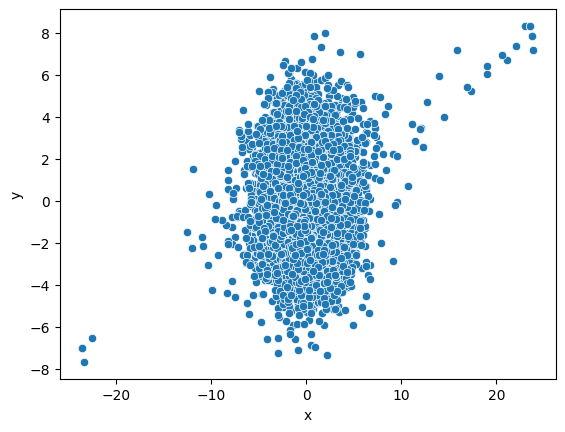

In [239]:
sns.scatterplot(df_pca2,x=df_pca2.x,y=df_pca2.y)

In [246]:
def GridSearchDBScan(min_samples_values,eps_values):
  min_samples_values = min_samples_values
  eps_values = eps_values
  results = []
  for min_samples in min_samples_values:
      for eps in eps_values:
        try:   
            startTime = datetime.datetime.now()
            print(f"Trying min_samples {min_samples} and eps {eps}")
            # Create and fit DBSCAN model
            dbscan = DBSCAN(min_samples=min_samples, eps=eps)
            dbscan.fit(df_scaled.iloc[:,:30])
            labels = dbscan.labels_

            if len(set(labels)) > 1:
                silhouette_avg = metrics.silhouette_score(df_scaled.iloc[:,:30], labels)
            else:
                silhouette_avg = -1
            
            duration = Timedelta(datetime.datetime.now()-startTime)
            print(f"Silhouette ({min_samples,eps}): {silhouette_avg}")
            print(f"Duration: {duration}")
            results.append({
                'min_samples': min_samples,
                'eps': eps,
                'silhouette_score': silhouette_avg,
                'num_clusters': len(set(labels)) - (1 if -1 in labels else 0),
                'num_noise': list(labels).count(-1)
            })
        except Exception as error:
           print(error)
  return results

results = GridSearchDBScan(min_samples_values=[20, 50, 100],eps_values=[2,5,7,10])
# The best result set uses min_samples_values = 10 and eps = 2
# I get better scores when I don't use the candidate metadata
# best_dbscan = DBSCAN(min_samples=10,eps=2)


Trying min_samples 20 and eps 2
Silhouette ((20, 2)): -0.22916806602167955
Duration: 0 days 00:00:03.726156
Trying min_samples 20 and eps 5
Silhouette ((20, 5)): 0.33994500453237747
Duration: 0 days 00:00:03.830750
Trying min_samples 20 and eps 7
Silhouette ((20, 7)): 0.5521563110507678
Duration: 0 days 00:00:09.994995
Trying min_samples 20 and eps 10
Silhouette ((20, 10)): 0.6774203237219939
Duration: 0 days 00:00:29.201872
Trying min_samples 50 and eps 2
Silhouette ((50, 2)): -1
Duration: 0 days 00:00:00.207689
Trying min_samples 50 and eps 5
Silhouette ((50, 5)): 0.33520141817049015
Duration: 0 days 00:00:04.041031
Trying min_samples 50 and eps 7
Silhouette ((50, 7)): 0.5542846584741948
Duration: 0 days 00:00:12.250055
Trying min_samples 50 and eps 10
Silhouette ((50, 10)): 0.6951027878143692
Duration: 0 days 00:00:31.495480
Trying min_samples 100 and eps 2
Silhouette ((100, 2)): -1
Duration: 0 days 00:00:00.178258
Trying min_samples 100 and eps 5
Silhouette ((100, 5)): 0.3295450381

In [244]:
# This filtered dataset gives better silhouette scores
df_num = df_scaled.iloc[:,:30]
df_num

,AFW,AMB,AND,BEH,BEW,DEN,DOB,DOE,ENE,EXT,...,REG,RUS,SAL,SAM,SBE,STA,VOL,ZEL,ZFS,ZIC
TestKey,,,,,,,,,,,,,,,,,,,,,
166962,-0.179202,-0.556284,0.189647,2.008444,-2.009825,0.028696,2.315124,-0.027724,0.643185,-0.674035,...,0.183008,-0.641363,-2.033862,-1.771075,2.029273,0.558304,0.763422,1.776459,3.112348,-0.188345
166963,-1.478036,-1.329131,0.579678,-0.016393,0.019103,1.621404,1.120569,-1.619469,-1.500694,-0.300951,...,1.486763,1.503589,-0.857414,-1.771075,0.856970,1.332344,0.357227,1.776459,2.018430,-0.578343
166964,1.119633,0.602985,2.139803,-0.421360,0.424889,-0.608387,0.324199,0.608974,-0.071441,-1.047119,...,-1.120747,0.073621,1.495482,-0.097978,-1.487635,-0.602756,0.357227,0.100768,0.195232,-2.138338
166965,2.851413,2.535101,2.919866,2.413412,-2.415611,-2.838178,-5.250392,2.837416,3.501691,3.429892,...,-2.859087,-3.501299,-2.033862,2.829943,2.029273,-2.537856,-2.486141,-2.831693,3.112348,-2.918336
166966,-1.045091,-1.329131,0.189647,-1.636263,1.642246,1.621404,-1.666727,-1.619469,0.643185,3.056808,...,1.052178,-0.641363,-0.073115,-0.516252,0.075435,1.332344,-0.048969,0.519691,0.195232,-0.188345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183637,-0.612147,0.602985,0.189647,-0.826328,0.830674,-1.245470,0.324199,1.245672,-0.786068,0.818302,...,0.617593,0.788605,-0.073115,-0.934527,0.075435,-0.602756,-0.861360,0.938613,1.289151,-0.188345
183638,-0.179202,1.375832,0.969710,0.793542,-0.792468,-1.882553,-0.073987,1.882370,0.643185,1.191386,...,0.183008,-0.641363,-0.857414,-1.352801,0.856970,-1.376796,-0.048969,1.357536,0.559872,-0.968342
183639,0.253743,-0.169861,-1.760509,1.198509,-1.198254,-0.608387,0.722384,0.608974,0.285872,-0.674035,...,-0.251577,-0.283871,-0.857414,-0.097978,0.856970,0.171284,-0.048969,0.100768,0.924511,1.761649


In [247]:
best_dbscan = DBSCAN(min_samples=50,eps=10)
best_dbscan.fit(df_scaled)
values, counts = np.unique(best_dbscan.labels_,return_counts=True)
counts[1:].sum()

16631

In [248]:
counts

array([   49, 16552,    79], dtype=int64)

In [249]:
values

array([-1,  0,  1], dtype=int64)

In [250]:
best_dbscan.labels_.argmin(-1)

1337

In [252]:
labels = pd.DataFrame(best_dbscan.labels_,index=df_scaled.index, columns=['label'])
labels

,label
TestKey,
166962,0
166963,0
166964,0
166965,0
166966,0
...,...
183637,0
183638,0
183639,0


In [253]:
dbscan_anom = labels[labels.label==-1]

In [254]:
anomalies2d = df_pca2.loc[dbscan_anom.index]

<Axes: xlabel='x', ylabel='y'>

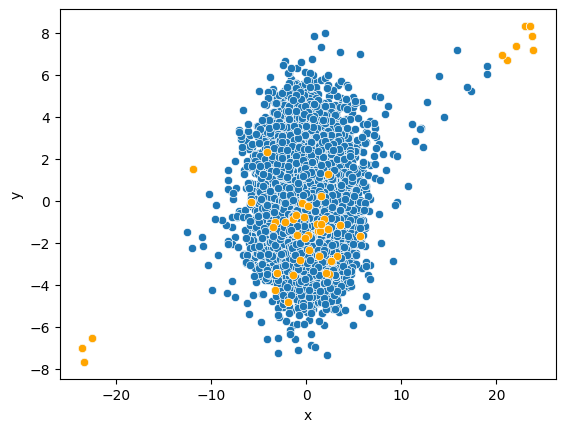

In [257]:
sns.scatterplot(df_pca2,x=df_pca2.x,y=df_pca2.y)
sns.scatterplot(anomalies2d,x=anomalies2d.x,y=anomalies2d.y,color="orange")

In [258]:
labels['is_anomaly'] = labels[['label']].map(lambda label : 1 if label==-1 else 0)

In [ ]:
labels.drop(columns=['label'],inplace=True)

In [260]:
os.chdir('..')
csv_path = os.path.join("csv")
os.chdir(csv_path)
labels.to_csv('dbscan_anomalies.csv')